Retrieving InsertionElectrodeDoc documents: 100%|██████████| 2647/2647 [00:00<00:00, 3191.25it/s]


average_voltage: 3.4956595151847942
energy_grav: 464.5282074246249
energy_vol: 1599.2451888063806
capacity_grav: 132.17600520644172
capacity_vol: 461.39089266564986
max_delta_volume: 0.04828250841620723
stability_charge: 0.06564785021625412
stability_discharge: 0.05204933831498557
fracA_charge: 0.048829902723965736
fracA_discharge: 0.16025651444588135
2647


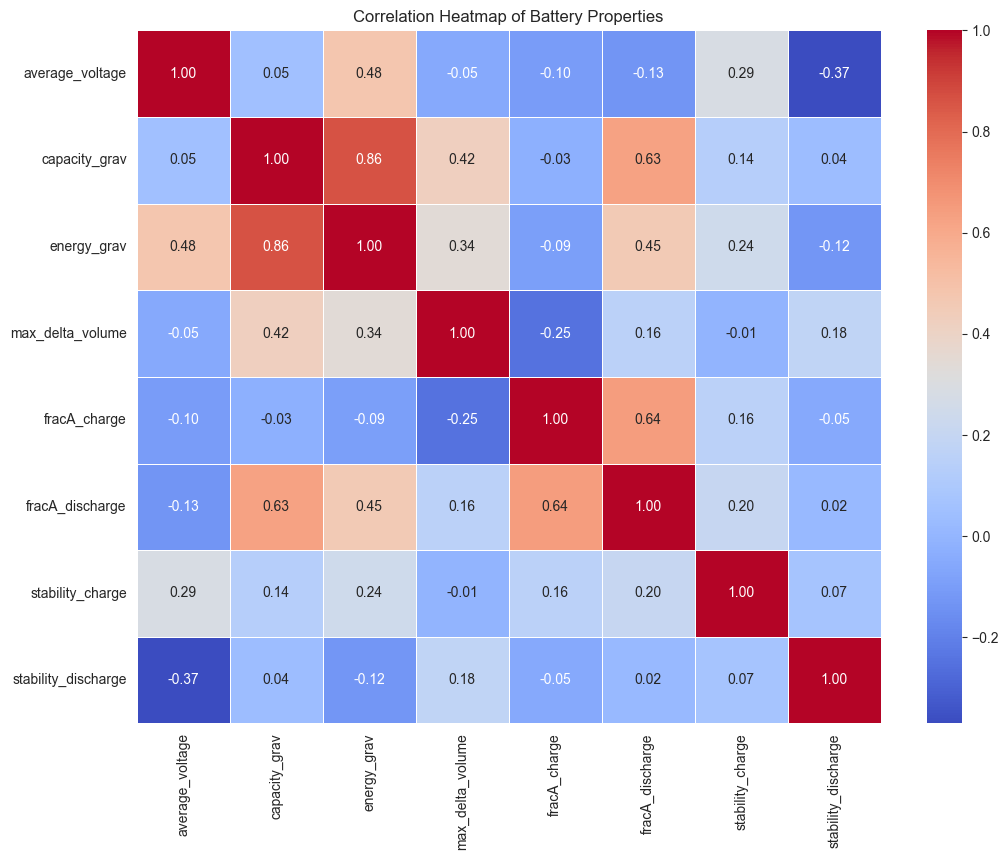


Data Size: 2647


In [44]:
# LITHIUM

from mp_api.client import MPRester
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


API_KEY = "4IeHY5jVcrgiKXNuAo6Jgs7yC0Z3hsli"
try:
    with MPRester(API_KEY) as mpr:
        # Query for Li-based cathode materials with high energy density
        docs = mpr.materials.insertion_electrodes.search(
        working_ion="Li", average_voltage = (0.0, 6.5), stability_charge=(0.0, 0.5), max_delta_volume=(0,1),
        # 0.1 > stability_charge (meV) starts to be unstable
        fields=[
            "battery_id", "formula_discharge", "average_voltage"
            , "energy_grav", "energy_vol", "capacity_grav", "capacity_vol", "stability_charge", "fracA_charge", "max_delta_volume", "stability_discharge", "fracA_discharge"
        ])

        Fields = "average_voltage", "energy_grav", "energy_vol", "capacity_grav", "capacity_vol", "max_delta_volume", "stability_charge", "stability_discharge", "fracA_charge", "fracA_discharge"

        def average_field(docs, field):
            vals = [getattr(d, field) for d in docs if getattr(d, field) is not None]
            return sum(vals) / len(vals)


        df = pd.DataFrame([doc.dict() for doc in docs])
        df.head(20)

        for f in Fields:
            avg = average_field(docs, f)
            print(f"{f}: {avg}")
        print(len(df))
        df.head(20)

         # Select only the numeric columns relevant to battery performance
    cols_to_analyze = ['average_voltage', 'capacity_grav', 'energy_grav',
                        'max_delta_volume',
                       'fracA_charge', 'fracA_discharge', 'stability_charge', 'stability_discharge']
    correlation_matrix = (df[cols_to_analyze].corr(method="spearman"))
    correlation_matrix.head()
    plt.figure(figsize=(12, 9))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title("Correlation Heatmap of Battery Properties")
    plt.show()
    print(f"\nData Size: {len(df)}")



except Exception as e:
    print(f"An error occurred: {e}")




mp-25959_Li
mp-26925_Li
mp-6838_Li
mp-26387_Li
mp-26531_Li
mp-1012865_Li


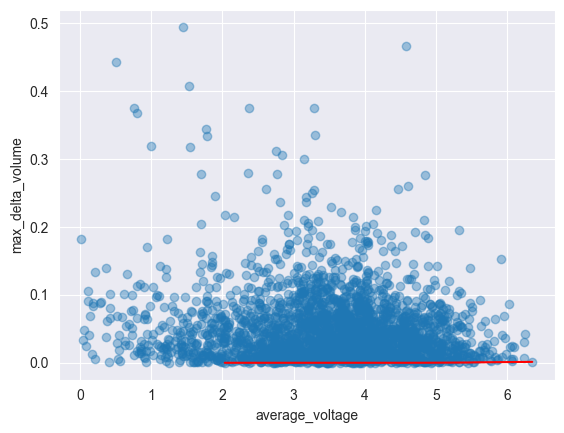

In [45]:
"""---- 1 ---- """

"""
X is maximized parameter
Y is minimized parameter
"""


import matplotlib.pyplot as plt

"""
Voltage VS Max Delta Volume
"""

X = 'average_voltage'
Y = 'max_delta_volume'



XParam = [doc.average_voltage for doc in docs] #verify that vaues correspond
YParam = [doc.max_delta_volume for doc in docs]

def plot_pareto_frontier(Xs, Ys, maxX=True, maxY=False, xlabel=X, ylabel=Y,):
    '''Pareto frontier selection process
    :param Xs: Series of X values
    :param Ys: Series of Y values
    :param maxX: True if maximizing on X
    :param maxY: True if maximizing on Y
    :param xlabel: plot label for X
    :parma ylabel: plot label for Y
    '''
    n = 0
    sorted_list = sorted([[Xs[i], Ys[i]] for i in range(len(Xs))], reverse=maxX) # Sorts values (descending if reverse = True)
    pareto_front = [sorted_list[0]]
    ids_list = []
    for pair in sorted_list[1:]:
        if maxY:
            if pair[1] >= pareto_front[-1][1]:
                pareto_front.append(pair)
                for id in docs:
                    if id.average_voltage == pair[0] or id.max_delta_volume == pair[0]:
                        print(f"{id.battery_id}") # Print ID and voltage
                        if id not in ids_list:
                            ids_list.append(id)

        else:
            if pair[1] <= pareto_front[-1][1]:
                pareto_front.append(pair)
                for id in docs:
                    if id.average_voltage == pair[0] or id.max_delta_volume == pair[0]:
                        print(f"{id.battery_id}") # Print ID and voltage
                        if id not in ids_list:
                            ids_list.append(id)


    '''Plotting process'''

    plt.scatter(Xs,Ys, alpha=0.4)
    pf_X = [pair[0] for pair in pareto_front]
    pf_Y = [pair[1] for pair in pareto_front]
    plt.plot(pf_X, pf_Y, color='red')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

    #return pareto_front

plot_pareto_frontier(XParam, YParam)


mp-557395_Li
mp-768501_Li
mp-26525_Li
mp-26997_Li
mp-26563_Li
mp-26141_Li
mp-25977_Li
mp-26165_Li
mp-25985_Li
mp-26269_Li
mp-26892_Li
mp-25979_Li
mp-561428_Li
mp-26355_Li
mp-26279_Li
mp-26001_Li
mp-26027_Li
mp-766524_Li
mp-25963_Li
mp-26361_Li
mp-26480_Li
mp-26007_Li
mp-25961_Li
mp-764912_Li
mp-26907_Li
mp-759084_Li
mp-504354_Li
mp-26195_Li
mp-26401_Li
mp-558431_Li
mp-541103_Li
mp-754427_Li
mp-26861_Li
mp-684495_Li
mp-705300_Li
mp-25959_Li
mp-26015_Li
mp-26925_Li
mp-26777_Li
mp-1111927_Li
mp-560212_Li
mp-26231_Li
mp-753435_Li
mp-27060_Li
mp-1219467_Li
mp-705398_Li
mp-27080_Li
mp-6838_Li
mp-18878_Li
mp-26274_Li
mp-25823_Li
mp-26835_Li
mp-705355_Li
mp-26397_Li
mp-32018_Li
mp-704942_Li
mp-771312_Li
mp-26811_Li
mp-26460_Li
mp-705334_Li
mp-31837_Li
mp-4995_Li
mp-26345_Li
mp-26991_Li
mp-26717_Li
mp-554855_Li
mp-773001_Li
mp-26143_Li
mp-26129_Li
mp-757440_Li
mp-772225_Li
mp-772423_Li
mp-27743_Li
mp-26120_Li
mp-31874_Li
mp-26359_Li
mp-772505_Li
mp-26077_Li
mp-773014_Li
mp-26853_Li
mp-757908_Li

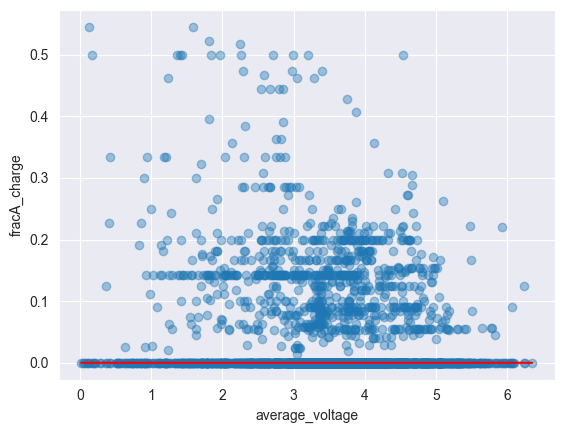

In [46]:
"""---- 2 ---- """

"""
X is maximized parameter
Y is minimized parameter
"""


import matplotlib.pyplot as plt

"""
Voltage VS fracA_charge
"""

X = 'average_voltage'
Y = 'fracA_charge'



XParam = [doc.average_voltage for doc in docs] #verify that vaues correspond
YParam = [doc.fracA_charge for doc in docs]

def plot_pareto_frontier(Xs, Ys, maxX=True, maxY=False, xlabel=X, ylabel=Y,):
    '''Pareto frontier selection process
    :param Xs: Series of X values
    :param Ys: Series of Y values
    :param maxX: True if maximizing on X
    :param maxY: True if maximizing on Y
    :param xlabel: plot label for X
    :parma ylabel: plot label for Y
    '''
    n = 0
    sorted_list = sorted([[Xs[i], Ys[i]] for i in range(len(Xs))], reverse=maxX) # Sorts values (descending if reverse = True)
    pareto_front = [sorted_list[0]]
    ids_list = []
    for pair in sorted_list[1:]:
        if maxY:
            if pair[1] >= pareto_front[-1][1]:
                pareto_front.append(pair)
                for id in docs:
                    if id.average_voltage == pair[0] or id.fracA_charge == pair[0]:
                        print(f"{id.battery_id}") # Print ID and voltage
                        if id not in ids_list:
                            ids_list.append(id)

        else:
            if pair[1] <= pareto_front[-1][1]:
                pareto_front.append(pair)
                for id in docs:
                    if id.average_voltage == pair[0] or id.fracA_charge == pair[0]:
                        print(f"{id.battery_id}") # Print ID and voltage
                        if id not in ids_list:
                            ids_list.append(id)


    '''Plotting process'''

    plt.scatter(Xs,Ys, alpha=0.4)
    pf_X = [pair[0] for pair in pareto_front]
    pf_Y = [pair[1] for pair in pareto_front]
    plt.plot(pf_X, pf_Y, color='red')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

    #return pareto_front

plot_pareto_frontier(XParam, YParam)


mp-768501_Li
mp-755193_Li
mp-561428_Li
mp-541103_Li
mp-1111927_Li
mp-554855_Li
mp-27743_Li
mp-1111150_Li
mp-18536_Li
mp-1111688_Li
mp-605034_Li
mp-560878_Li
mp-753171_Li
mp-556417_Li
mp-584429_Li
mp-752752_Li
mp-768472_Li
mp-758265_Li
mp-504230_Li
mp-27309_Li
mp-554799_Li
mp-849770_Li
mp-768451_Li
mp-17754_Li
mp-25449_Li
mp-771660_Li
mp-541384_Li
mp-761124_Li
mp-17387_Li
mp-25265_Li
mp-557397_Li
mp-759347_Li
mp-773018_Li
mp-504210_Li
mp-555003_Li
mp-776296_Li
mp-656887_Li
mp-771905_Li
mp-32080_Li
mp-560465_Li
mp-767534_Li
mp-778008_Li
mp-734805_Li
mp-754849_Li
mp-555112_Li
mp-558111_Li
mp-753047_Li
mp-26051_Li
mp-18987_Li
mp-19395_Li
mp-753347_Li
mp-772650_Li
mp-1111263_Li
mp-759223_Li
mp-1113694_Li
mp-26013_Li
mp-752823_Li
mp-18934_Li
mp-554701_Li
mp-760343_Li
mp-540767_Li
mp-21778_Li
mp-764273_Li
mp-23895_Li
mp-1110680_Li
mp-1111439_Li
mp-26371_Li
mp-559279_Li
mp-541668_Li
mp-504729_Li
mp-776421_Li
mp-553997_Li
mp-26744_Li
mp-758674_Li
mp-25403_Li
mp-754594_Li
mp-26727_Li
mp-25827_Li

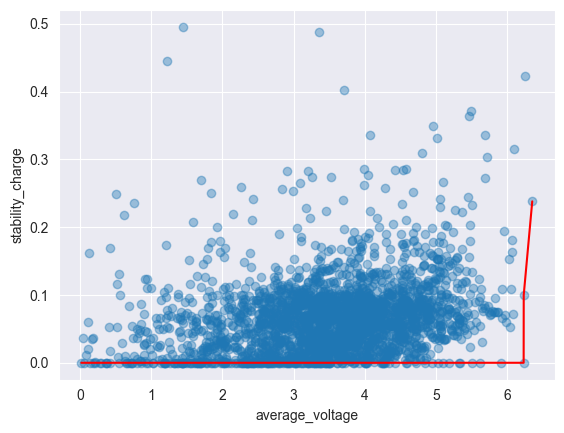

In [47]:
"""---- 3 ---- """

"""
X is maximized parameter
Y is minimized parameter
"""


import matplotlib.pyplot as plt

"""
Voltage VS Stability_charge
"""

X = 'average_voltage'
Y = 'stability_charge'



XParam = [doc.average_voltage for doc in docs] #verify that vaues correspond
YParam = [doc.stability_charge for doc in docs]

def plot_pareto_frontier(Xs, Ys, maxX=True, maxY=False, xlabel=X, ylabel=Y,):
    '''Pareto frontier selection process
    :param Xs: Series of X values
    :param Ys: Series of Y values
    :param maxX: True if maximizing on X
    :param maxY: True if maximizing on Y
    :param xlabel: plot label for X
    :parma ylabel: plot label for Y
    '''
    n = 0
    sorted_list = sorted([[Xs[i], Ys[i]] for i in range(len(Xs))], reverse=maxX) # Sorts values (descending if reverse = True)
    pareto_front = [sorted_list[0]]
    ids_list = []
    for pair in sorted_list[1:]:
        if maxY:
            if pair[1] >= pareto_front[-1][1]:
                pareto_front.append(pair)
                for id in docs:
                    if id.average_voltage == pair[0] or id.stability_charge == pair[0]:
                        print(f"{id.battery_id}") # Print ID and voltage
                        if id not in ids_list:
                            ids_list.append(id)

        else:
            if pair[1] <= pareto_front[-1][1]:
                pareto_front.append(pair)
                for id in docs:
                    if id.average_voltage == pair[0] or id.stability_charge == pair[0]:
                        print(f"{id.battery_id}") # Print ID and voltage
                        if id not in ids_list:
                            ids_list.append(id)


    '''Plotting process'''

    plt.scatter(Xs,Ys, alpha=0.4)
    pf_X = [pair[0] for pair in pareto_front]
    pf_Y = [pair[1] for pair in pareto_front]
    plt.plot(pf_X, pf_Y, color='red')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

    #return pareto_front

plot_pareto_frontier(XParam, YParam)


mp-768501_Li
mp-755193_Li
mp-26997_Li
mp-25977_Li
mp-26001_Li
mp-504354_Li
mp-26015_Li
mp-1111927_Li
mp-18878_Li
mp-4995_Li
mp-17664_Li
mp-1111150_Li
mp-758760_Li
mp-25991_Li
mp-25261_Li
mp-562404_Li
mp-22243_Li
mp-21650_Li
mp-26952_Li
mp-26019_Li
mp-3731_Li
mp-22417_Li
mp-18932_Li
mp-26975_Li
mp-26035_Li
mp-752929_Li
mp-19103_Li
mp-560878_Li
mp-26955_Li
mp-675534_Li
mp-753573_Li
mp-674219_Li
mp-771112_Li
mp-26138_Li
mp-753051_Li
mp-25838_Li
mp-18988_Li
mp-3540_Li
mp-18274_Li
mp-9158_Li
mp-756057_Li
mp-757572_Li
mp-25983_Li
mp-780857_Li
mp-554324_Li
mp-754012_Li
mp-26977_Li
mp-756482_Li
mp-26003_Li
mp-26965_Li
mp-26757_Li
mp-21633_Li
mp-755620_Li
mp-559240_Li
mp-26949_Li
mp-25201_Li
mp-752521_Li
mp-19131_Li
mp-18968_Li
mp-18793_Li
mp-752541_Li
mp-759232_Li
mp-758123_Li
mp-26005_Li
mp-26227_Li
mp-768437_Li
mp-761124_Li
mp-763186_Li
mp-27007_Li
mp-764333_Li
mp-17387_Li
mp-753224_Li
mp-25265_Li
mp-773051_Li
mp-753099_Li
mp-18997_Li
mp-22526_Li
mp-866271_Li
mp-20052_Li
mp-19511_Li
mp-26967

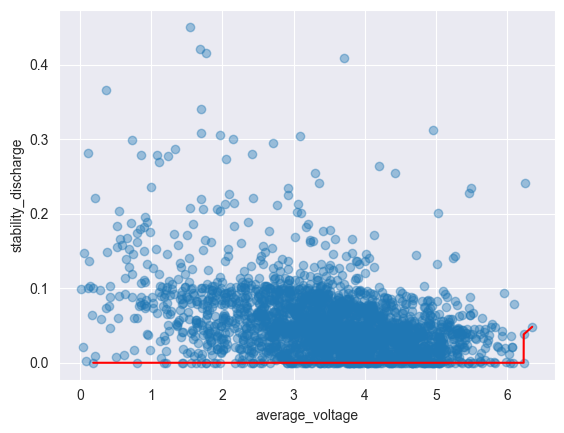

In [48]:
"""---- 4 ---- """

"""
X is maximized parameter
Y is minimized parameter
"""


import matplotlib.pyplot as plt

"""
Voltage VS stability_charge
"""

X = 'average_voltage'
Y = 'stability_discharge'



XParam = [doc.average_voltage for doc in docs] #verify that vaues correspond
YParam = [doc.stability_discharge for doc in docs]

def plot_pareto_frontier(Xs, Ys, maxX=True, maxY=False, xlabel=X, ylabel=Y,):
    '''Pareto frontier selection process
    :param Xs: Series of X values
    :param Ys: Series of Y values
    :param maxX: True if maximizing on X
    :param maxY: True if maximizing on Y
    :param xlabel: plot label for X
    :parma ylabel: plot label for Y
    '''
    n = 0
    sorted_list = sorted([[Xs[i], Ys[i]] for i in range(len(Xs))], reverse=maxX) # Sorts values (descending if reverse = True)
    pareto_front = [sorted_list[0]]
    ids_list = []
    for pair in sorted_list[1:]:
        if maxY:
            if pair[1] >= pareto_front[-1][1]:
                pareto_front.append(pair)
                for id in docs:
                    if id.average_voltage == pair[0] or id.stability_discharge == pair[0]:
                        print(f"{id.battery_id}") # Print ID and voltage
                        if id not in ids_list:
                            ids_list.append(id)

        else:
            if pair[1] <= pareto_front[-1][1]:
                pareto_front.append(pair)
                for id in docs:
                    if id.average_voltage == pair[0] or id.stability_discharge == pair[0]:
                        print(f"{id.battery_id}") # Print ID and voltage
                        if id not in ids_list:
                            ids_list.append(id)


    '''Plotting process'''

    plt.scatter(Xs,Ys, alpha=0.4)
    pf_X = [pair[0] for pair in pareto_front]
    pf_Y = [pair[1] for pair in pareto_front]
    plt.plot(pf_X, pf_Y, color='red')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

    #return pareto_front

plot_pareto_frontier(XParam, YParam)


mp-557395_Li
mp-768501_Li
mp-26997_Li
mp-26141_Li
mp-25977_Li
mp-25985_Li
mp-26269_Li
mp-759383_Li
mp-758792_Li


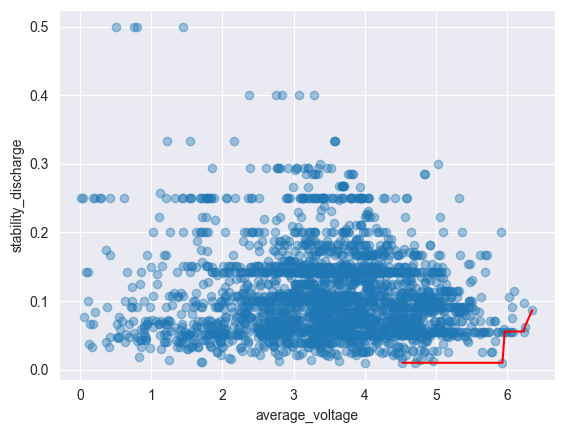

In [49]:


"""---- 5 ---- """

"""
X is maximized parameter
Y is minimized parameter
"""


import matplotlib.pyplot as plt

"""
Voltage VS stability_charge
"""

X = 'average_voltage'
Y = 'stability_discharge'



XParam = [doc.average_voltage for doc in docs] #verify that vaues correspond
YParam = [doc.fracA_discharge - doc.fracA_charge for doc in docs] #verify that vaues correspond


def plot_pareto_frontier(Xs, Ys, maxX=True, maxY=False, xlabel=X, ylabel=Y,):
    '''Pareto frontier selection process
    :param Xs: Series of X values
    :param Ys: Series of Y values
    :param maxX: True if maximizing on X
    :param maxY: True if maximizing on Y
    :param xlabel: plot label for X
    :parma ylabel: plot label for Y
    '''
    n = 0
    sorted_list = sorted([[Xs[i], Ys[i]] for i in range(len(Xs))], reverse=maxX) # Sorts values (descending if reverse = True)
    pareto_front = [sorted_list[0]]
    ids_list = []
    for pair in sorted_list[1:]:
        if maxY:
            if pair[1] >= pareto_front[-1][1]:
                pareto_front.append(pair)
                for id in docs:
                    if id.average_voltage == pair[0] or id.stability_discharge == pair[0]:
                        print(f"{id.battery_id}") # Print ID and voltage
                        if id not in ids_list:
                            ids_list.append(id)

        else:
            if pair[1] <= pareto_front[-1][1]:
                pareto_front.append(pair)
                for id in docs:
                    if id.average_voltage == pair[0] or id.stability_discharge == pair[0]:
                        print(f"{id.battery_id}") # Print ID and voltage
                        if id not in ids_list:
                            ids_list.append(id)


    '''Plotting process'''

    plt.scatter(Xs,Ys, alpha=0.4)
    pf_X = [pair[0] for pair in pareto_front]
    pf_Y = [pair[1] for pair in pareto_front]
    plt.plot(pf_X, pf_Y, color='red')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

    #return pareto_front

plot_pareto_frontier(XParam, YParam)


Want to find the change in fracA because it shows that there is more transfer of ions which is good

In [50]:
"""
FracA charge vs discharge
"""



'\nFracA charge vs discharge\n'